# EV Session-Energy Model — residential charging, Dingle (Ireland)

**EnerTEF · TEF-EV · Service 4 — EV-User Charging and Usage Profiles Prediction · D2.2 §2.5.4**

Predicts the **energy a home charging session will deliver** (kWh) at the q10 / q50 / q90 quantiles,
from context available just before the session starts: recent driving, time since the last charge,
the tariff band and the PV already generated that day. Downstream smart-charging gets a point
estimate *and* an uncertainty band.

This notebook is the complete, self-contained model pipeline: it loads the dataset, reconstructs the
pre-session context of every real session, selects the learning algorithm with a rule fixed before
the experiment, trains and evaluates the final model, and writes it — with its Hugging Face model
card — to `Data/models/`. The exploratory analysis behind the service (charging behaviour, timing
and volume heads, counterfactuals) is in `EV_Charging_Analysis.ipynb`.

## Data access

The **Residential Energy Dataset with Electric Vehicles, PV Generation and Tariff Variability in
Ireland** (Scientific Data 13:834, 2026) describes four real households and is **not redistributed
in this repository**. Obtain it from its owners via the data paper, then place (or point to) it:

```
Data/
  JourneyCharge/idNN_Sorted_Mobility.csv   # journeys + charging events
  EnergyStreams/idNN_merged_30min*.csv     # 30-min solar_kWh + elec_price
```

or set `DINGLE_DATASET_ROOT` to the folder that contains `JourneyCharge/` and `EnergyStreams/`.

## How to run

```bash
python -m venv .venv
.venv\Scripts\activate            # macOS / Linux: source .venv/bin/activate
pip install -r requirements.txt
jupyter lab EV_Session_Energy_Model.ipynb
```

Run it top to bottom from the repository root (well under a minute).

| § | Section | Produces |
|---|---|---|
| 1 | Setup | paths, constants, library versions |
| 2 | Data | charging sessions, journeys and energy streams per household |
| 3 | Features | the 7-feature pre-session context of every session, leakage-safe |
| 4 | Split and baseline | chronological 80/20 split and the physics-lite baseline |
| 5 | Algorithm bake-off | GBR vs LightGBM vs XGBoost over 3 seeds and the pre-registered rule's verdict |
| 6 | Final model and evaluation | hold-out accuracy vs the baseline, per household |
| 7 | Export | `Data/models/`: `.joblib` model, metrics, bake-off, model card |
| 8 | Publish to Hugging Face | opt-in upload of `Data/models/` |

## 1 · Setup

In [1]:
import json
import os
import platform
import statistics
import time
from datetime import datetime, timedelta, timezone
from importlib.metadata import version
from pathlib import Path

# joblib cannot count physical cores on recent Windows (no `wmic`) and prints a traceback when
# LightGBM asks for them; a core count below the logical total makes it skip that probe.
if os.name == "nt":
    os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(max(1, (os.cpu_count() or 2) // 2)))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

ROOT = Path.cwd()
DATA_DIR = Path(os.environ.get("DINGLE_DATASET_ROOT") or ROOT / "Data")
MODEL_DIR = ROOT / "Data" / "models"
if not (DATA_DIR / "JourneyCharge").is_dir() or not (DATA_DIR / "EnergyStreams").is_dir():
    raise FileNotFoundError(
        f"Dataset not found under {DATA_DIR}: expected JourneyCharge/ and EnergyStreams/. "
        "Place the restricted dataset in Data/ or set DINGLE_DATASET_ROOT (see 'Data access' above)."
    )
MODEL_DIR.mkdir(parents=True, exist_ok=True)

HOUSEHOLDS = ["id01", "id02", "id03", "id04"]
QUANTILES = {"q10": 0.1, "q50": 0.5, "q90": 0.9}
TEST_FRACTION = 0.2                       # most recent fifth of the sessions is held out
MODEL_VERSION = "1.0.0"
HF_REPO = "EnerTEF/Service4-SessionEnergy"
GITHUB_REPO = "https://github.com/ENERTEF/TEF-EV-Service-4----EV-User-Charging-and-Usage-Profiles-Prediction-Service"

LIBS = {lib: version(lib) for lib in ("numpy", "pandas", "scikit-learn", "lightgbm", "xgboost", "joblib")}
print(f"dataset: {DATA_DIR.relative_to(ROOT).as_posix() if DATA_DIR.is_relative_to(ROOT) else '$DINGLE_DATASET_ROOT'}")
print(f"python {platform.python_version()} · " + " · ".join(f"{lib} {v}" for lib, v in LIBS.items()))

dataset: Data
python 3.11.9 · numpy 1.26.4 · pandas 2.2.3 · scikit-learn 1.5.2 · lightgbm 4.5.0 · xgboost 2.1.3 · joblib 1.4.2


## 2 · Data — sessions, journeys and energy streams

Per household, `JourneyCharge/` holds the event log (journeys with distance, charging sessions with
delivered energy) and `EnergyStreams/` the 30-minute solar generation and electricity price. Event
timestamps are naive and read as UTC; charging events without positive energy and journeys without
positive distance are dropped. Each session gets a **tariff band** from the price in its start slot,
classified by the household's own price terciles (off-peak ≤ lower tercile, peak ≥ upper tercile,
shoulder in between).

In [2]:
def find_file(subdir: str, household: str) -> Path | None:
    for pattern in (f"{household}_*.csv", f"{household}*.csv"):
        matches = sorted((DATA_DIR / subdir).glob(pattern))
        if matches:
            return matches[0]
    return None


def parse_event_ts(value) -> datetime | None:
    try:
        return datetime.strptime(str(value).strip(), "%Y-%m-%d %H:%M:%S").replace(tzinfo=timezone.utc)
    except ValueError:
        return None


def parse_float(value) -> float | None:
    text = str(value).strip()
    try:
        return float(text) if text else None
    except ValueError:
        return None


def charging_minutes(value) -> float | None:
    # CHARGING_TIME as HH:MM:SS → minutes (used only when end_time is missing).
    parts = str(value).strip().split(":")
    try:
        h, m, s = (int(p) for p in parts)
    except ValueError:
        return None
    return h * 60 + m + s / 60.0


def load_events(household: str) -> tuple[list[dict], list[dict]]:
    # Charging sessions and journeys of one household.
    log = pd.read_csv(find_file("JourneyCharge", household), dtype=str, keep_default_na=False)
    sessions, journeys = [], []
    for row in log.to_dict("records"):
        event = (row.get("event_type") or "").strip().lower()
        start = parse_event_ts(row.get("start_time", ""))
        if start is None:
            continue
        if event == "charging":
            energy = parse_float(row.get("ENERGY", ""))
            if energy is None or energy <= 0:
                continue
            end = parse_event_ts(row.get("end_time", ""))
            if end is None:
                end = start + timedelta(minutes=charging_minutes(row.get("CHARGING_TIME", "")) or 0.0)
            sessions.append({"start": start, "end": end, "energy_kwh": energy})
        elif event == "journey":
            distance = parse_float(row.get("Distance", ""))
            if distance is not None and distance > 0:
                journeys.append({"start": start, "distance_km": distance})
    return sessions, journeys


def load_stream(household: str) -> dict[datetime, tuple[float | None, float | None]]:
    # 30-min slot → (solar_kWh, elec_price).
    df = pd.read_csv(find_file("EnergyStreams", household), dtype=str, keep_default_na=False)
    stream = {}
    for ts, solar, price in zip(df["timestamp"], df["solar_kWh"], df["elec_price"]):
        try:
            slot = datetime.fromisoformat(ts.strip()).astimezone(timezone.utc)
        except ValueError:
            continue
        stream[slot] = (parse_float(solar), parse_float(price))
    return stream


def slot_of(ts: datetime) -> datetime:
    return ts.replace(minute=0 if ts.minute < 30 else 30, second=0, microsecond=0)


def tariff_band(price: float | None, terciles: tuple[float, float] | None) -> str | None:
    if price is None or terciles is None:
        return None
    low, high = terciles
    return "off_peak" if price <= low else "peak" if price >= high else "shoulder"


data = {}
for hid in HOUSEHOLDS:
    sessions, journeys = load_events(hid)
    stream = load_stream(hid)
    prices = sorted(p for _, p in stream.values() if p is not None)
    terciles = tuple(statistics.quantiles(prices, n=3)) if len(prices) >= 3 and prices[0] != prices[-1] else None
    for s in sessions:
        s["tariff_band"] = tariff_band(stream.get(slot_of(s["start"]), (None, None))[1], terciles)
    data[hid] = {"sessions": sessions, "journeys": journeys, "stream": stream}

display(pd.DataFrame(
    {hid: {"charging sessions": len(d["sessions"]), "journeys": len(d["journeys"]),
           "30-min stream slots": len(d["stream"]),
           "first session": min(s["start"] for s in d["sessions"]).date(),
           "last session": max(s["start"] for s in d["sessions"]).date(),
           "median energy (kWh)": round(float(np.median([s["energy_kwh"] for s in d["sessions"]])), 1)}
     for hid, d in data.items()}
).T)

,charging sessions,journeys,30-min stream slots,first session,last session,median energy (kWh)
id01,153,2314,52945,2021-02-04,2022-01-25,10.9
id02,292,3481,54095,2021-02-01,2022-01-30,24.0
id03,89,6265,52129,2021-02-11,2022-01-27,29.2
id04,200,6223,53569,2021-02-05,2022-01-30,29.1


## 3 · Features — the pre-session context

A prediction is **issued at the moment a session starts**, from what is known up to then. For every
real session the context is rebuilt from the event log and the energy stream, strictly before the
session start:

| Feature | Meaning |
|---|---|
| `recent_trip_km` | distance driven since the previous session ended (last 24 h for the first session) |
| `trips_today` | journeys started earlier the same day |
| `hours_since_last_charge` | hours since the previous session ended (18 h prior for the first session) |
| `tariff_ordinal` | tariff band at the start: off-peak 0, shoulder 1, standard 2 (unknown), peak 3 |
| `pv_today_kwh` | PV generated since midnight |
| `hour_of_day` | fractional hour of the session start (UTC) |
| `is_weekend` | 1 on Saturday / Sunday |

In [3]:
FEATURES = ["recent_trip_km", "trips_today", "hours_since_last_charge", "tariff_ordinal",
            "pv_today_kwh", "hour_of_day", "is_weekend"]
TARIFF_ORDINAL = {"off_peak": 0, "shoulder": 1, "standard": 2, "peak": 3}
DEFAULT_HOURS_SINCE_LAST_CHARGE = 18.0


def pv_today_kwh(stream: dict, until: datetime) -> float:
    cursor, total = until.replace(hour=0, minute=0, second=0, microsecond=0), 0.0
    while cursor < until:
        solar = stream.get(slot_of(cursor), (None, None))[0]
        if solar:
            total += solar
        cursor += timedelta(minutes=30)
    return round(total, 3)


rows = []
for hid in HOUSEHOLDS:
    d = data[hid]
    prev_end = None
    for s in sorted(d["sessions"], key=lambda x: x["start"]):
        start = s["start"]
        window_start = prev_end if prev_end is not None else start - timedelta(hours=24)
        rows.append({
            "household": hid,
            "start": start,
            "recent_trip_km": round(sum(j["distance_km"] for j in d["journeys"] if window_start <= j["start"] < start), 3),
            "trips_today": sum(1 for j in d["journeys"] if j["start"].date() == start.date() and j["start"] < start),
            "hours_since_last_charge": (max(0.0, (start - prev_end).total_seconds() / 3600.0)
                                        if prev_end is not None else DEFAULT_HOURS_SINCE_LAST_CHARGE),
            "tariff_ordinal": float(TARIFF_ORDINAL.get(s["tariff_band"] or "standard", 2)),
            "pv_today_kwh": pv_today_kwh(d["stream"], start),
            "hour_of_day": start.hour + start.minute / 60.0,
            "is_weekend": 1.0 if start.weekday() >= 5 else 0.0,
            "energy_kwh": s["energy_kwh"],
        })
        prev_end = s["end"]
table = pd.DataFrame(rows)
print(f"{len(table)} sessions with reconstructed context")
display(table[FEATURES + ["energy_kwh"]].describe().T.round(2))

734 sessions with reconstructed context


,count,mean,std,min,25%,50%,75%,max
recent_trip_km,734.0,118.94,140.06,0.00,4.20,71.79,186.19,1133.40
trips_today,734.0,8.59,7.72,0.00,0.00,8.00,14.00,37.00
hours_since_last_charge,734.0,38.30,58.63,0.00,6.49,15.68,52.00,607.56
tariff_ordinal,734.0,0.87,0.53,0.00,1.00,1.00,1.00,3.00
pv_today_kwh,734.0,2.54,3.63,0.00,0.00,0.47,4.17,15.83
hour_of_day,734.0,15.70,7.47,0.00,11.66,18.63,21.70,23.97
is_weekend,734.0,0.26,0.44,0.00,0.00,0.00,1.00,1.00
energy_kwh,734.0,26.74,19.60,0.01,8.70,23.97,43.39,71.27


## 4 · Chronological split and the baseline

Sessions are sorted by start time across households; the earlier **80 %** train, the most recent
**20 %** are held out. The **baseline** is the physics-lite rule a service can use without a trained
model: energy = recent distance × 0.18 kWh/km (+5 % per trip beyond the first), clamped to
1–80 kWh, with a ±25 % band.

In [4]:
order = np.argsort([t.timestamp() for t in table.start])
table = table.iloc[order].reset_index(drop=True)
split = int(len(table) * (1 - TEST_FRACTION))
train, test = table.iloc[:split], table.iloc[split:]
X_tr, y_tr = train[FEATURES].to_numpy(dtype=float), train.energy_kwh.to_numpy()
X_te, y_te = test[FEATURES].to_numpy(dtype=float), test.energy_kwh.to_numpy()


def baseline(frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    energy = frame.recent_trip_km.to_numpy() * 0.18 * (1.0 + 0.05 * np.maximum(0, frame.trips_today.to_numpy() - 1))
    energy = np.clip(energy, 1.0, 80.0)
    return np.maximum(0.0, energy * 0.75 - 1.0), energy, np.minimum(80.0 * 1.2, energy * 1.25 + 1.0)


def scores(actual: np.ndarray, lo: np.ndarray, mid: np.ndarray, hi: np.ndarray) -> dict:
    err = mid - actual
    return {
        "mae_kwh": round(float(np.mean(np.abs(err))), 3),
        "rmse_kwh": round(float(np.sqrt(np.mean(err ** 2))), 3),
        "bias_kwh": round(float(np.mean(err)), 3),
        "coverage_q10_q90_pct": round(100 * float(np.mean((lo <= actual) & (actual <= hi))), 1),
    }


baseline_scores = scores(y_te, *baseline(test))
print(f"train {len(train)} sessions ({train.start.min():%d %b %Y} → {train.start.max():%d %b %Y}), "
      f"hold-out {len(test)} sessions ({test.start.min():%d %b %Y} → {test.start.max():%d %b %Y})")
print("baseline on the hold-out:", baseline_scores)

train 587 sessions (01 Feb 2021 → 24 Nov 2021), hold-out 147 sessions (24 Nov 2021 → 30 Jan 2022)
baseline on the hold-out: {'mae_kwh': 18.723, 'rmse_kwh': 25.883, 'bias_kwh': -2.59, 'coverage_q10_q90_pct': 36.1}


## 5 · Algorithm bake-off — why this algorithm

Three gradient-boosting libraries compete as q10 / q50 / q90 quantile regressors of session energy:
**scikit-learn `GradientBoostingRegressor`** (the incumbent), **LightGBM** and **XGBoost**. They see
the same sessions and split, get the same capacity translated to each library's parameter names
(200 trees, depth 3, learning rate 0.05, minimum leaf size 25, row subsampling 0.85) with no
per-library tuning, and run over three seeds, so each gap can be compared with the noise from the
seed alone. Quantile predictions are sorted before scoring.

**The selection rule was fixed before the experiment was run:** the primary metric is the hold-out
q50 MAE averaged over the seeds. A challenger replaces GBR only if its MAE is **at least 3 % lower**,
**and** the gap exceeds the seed-to-seed MAE range of either model, **and** its q10–q90 coverage is at
most **5 points** below GBR's. Otherwise GBR stays. Training time is reported but is not a criterion.

| Algorithm | Hold-out q50 MAE (kWh), mean [min–max] | q10–q90 coverage | Fit time (3 quantiles) | Verdict |
|---|---|---|---|---|
| scikit-learn GBR | 10.38 [10.29–10.46] | 80.3 % | 1.1 s | incumbent — **selected** |
| LightGBM | 10.36 [10.34–10.38] | 79.8 % | 0.1 s | rejected — MAE gain +0.2 % is below the 3 % bar; gap is within the 1.7 % seed-to-seed range |
| XGBoost | 10.28 [10.20–10.33] | 80.1 % | 0.4 s | rejected — MAE gain +1.0 % is below the 3 % bar; gap is within the 1.7 % seed-to-seed range |

MAE over seeds 42, 43, 44.

**scikit-learn GBR is retained** — no challenger cleared the rule.

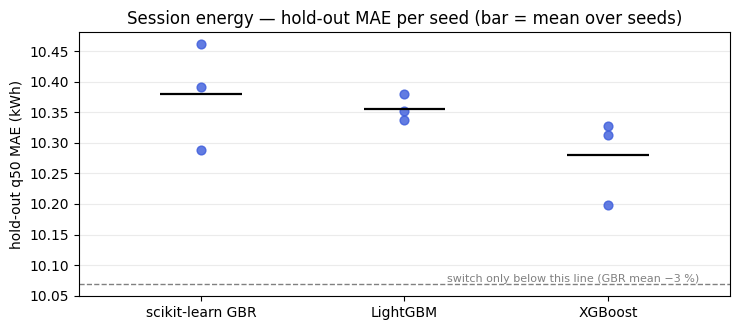

In [5]:
SEEDS = (42, 43, 44)
INCUMBENT = "sklearn_gbr"
MIN_GAIN_PCT, MAX_COVERAGE_DROP_PTS = 3.0, 5.0
LABELS = {"sklearn_gbr": "scikit-learn GBR", "lightgbm": "LightGBM", "xgboost": "XGBoost"}

# (estimator class, name of its quantile-level argument, capacity-matched parameters)
ESTIMATORS = {
    "sklearn_gbr": (GradientBoostingRegressor, "alpha", {
        "loss": "quantile", "init": "zero", "n_estimators": 200, "max_depth": 3,
        "learning_rate": 0.05, "min_samples_leaf": 25, "subsample": 0.85}),
    "lightgbm": (LGBMRegressor, "alpha", {
        "objective": "quantile", "n_estimators": 200, "max_depth": 3, "num_leaves": 8,
        "learning_rate": 0.05, "min_child_samples": 25, "subsample": 0.85, "subsample_freq": 1, "verbose": -1}),
    "xgboost": (XGBRegressor, "quantile_alpha", {
        "objective": "reg:quantileerror", "tree_method": "hist", "n_estimators": 200, "max_depth": 3,
        "learning_rate": 0.05, "min_child_weight": 25, "subsample": 0.85}),
}


def predict_sorted(models: dict, X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    return tuple(np.sort(np.vstack([models[q].predict(X) for q in QUANTILES]), axis=0))


results, fitted_42 = {}, {}
for name, (cls, alpha_arg, params) in ESTIMATORS.items():
    runs = []
    for seed in SEEDS:
        models, fit_s = {}, 0.0
        for q, alpha in QUANTILES.items():
            est = cls(**params, **{alpha_arg: alpha}, random_state=seed)
            t0 = time.perf_counter()
            est.fit(X_tr, y_tr)
            fit_s += time.perf_counter() - t0
            models[q] = est
        runs.append({"seed": seed, "fit_s": round(fit_s, 2), **scores(y_te, *predict_sorted(models, X_te))})
        if seed == 42:
            fitted_42[name] = models
    mae = [r["mae_kwh"] for r in runs]
    results[name] = {"mae_kwh": round(float(np.mean(mae)), 3), "mae_min_kwh": min(mae), "mae_max_kwh": max(mae),
                     "coverage_pct": round(float(np.mean([r["coverage_q10_q90_pct"] for r in runs])), 1),
                     "fit_s": round(float(np.mean([r["fit_s"] for r in runs])), 2), "runs": runs}

verdicts = {}
inc = results[INCUMBENT]
for name, res in results.items():
    if name == INCUMBENT:
        continue
    gain = 100 * (inc["mae_kwh"] - res["mae_kwh"]) / inc["mae_kwh"]
    noise = 100 * max(inc["mae_max_kwh"] - inc["mae_min_kwh"], res["mae_max_kwh"] - res["mae_min_kwh"]) / inc["mae_kwh"]
    drop = inc["coverage_pct"] - res["coverage_pct"]
    failures = []
    if gain < MIN_GAIN_PCT:
        failures.append(f"MAE gain {gain:+.1f} % is below the {MIN_GAIN_PCT:g} % bar")
    if gain <= noise:
        failures.append(f"gap is within the {noise:.1f} % seed-to-seed range")
    if drop > MAX_COVERAGE_DROP_PTS:
        failures.append(f"coverage drops {drop:.1f} pts (limit {MAX_COVERAGE_DROP_PTS:g})")
    verdicts[name] = {"mae_gain_pct": round(gain, 1), "seed_range_pct": round(noise, 1),
                      "coverage_drop_pts": round(drop, 1), "passes": not failures,
                      "reason": "; ".join(failures) if failures else
                      f"MAE {gain:.1f} % lower (> {MIN_GAIN_PCT:g} % and > {noise:.1f} % seed range), coverage {-drop:+.1f} pts"}
passing = [n for n, v in verdicts.items() if v["passes"]]
SELECTED = max(passing, key=lambda n: verdicts[n]["mae_gain_pct"]) if passing else INCUMBENT


def selection_markdown() -> str:
    lines = ["| Algorithm | Hold-out q50 MAE (kWh), mean [min–max] | q10–q90 coverage | Fit time (3 quantiles) | Verdict |",
             "|---|---|---|---|---|"]
    for name, res in results.items():
        if name == INCUMBENT:
            verdict = "incumbent — **selected**" if SELECTED == INCUMBENT else "incumbent — replaced"
        else:
            verdict = ("**selected** — " if SELECTED == name else "rejected — ") + verdicts[name]["reason"]
        lines.append(f"| {LABELS[name]} | {res['mae_kwh']:.2f} [{res['mae_min_kwh']:.2f}–{res['mae_max_kwh']:.2f}] "
                     f"| {res['coverage_pct']:.1f} % | {res['fit_s']:.1f} s | {verdict} |")
    decision = (f"**{LABELS[INCUMBENT]} is retained** — no challenger cleared the rule."
                if SELECTED == INCUMBENT else f"**{LABELS[SELECTED]} replaces {LABELS[INCUMBENT]}** — it cleared every condition.")
    return "\n".join(lines) + f"\n\nMAE over seeds {', '.join(map(str, SEEDS))}.\n\n{decision}"


display(Markdown(selection_markdown()))

bar = inc["mae_kwh"] * (1 - MIN_GAIN_PCT / 100)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for i, (name, res) in enumerate(results.items()):
    maes = [r["mae_kwh"] for r in res["runs"]]
    ax.scatter([i] * len(maes), maes, s=40, color="#3b5bdb", alpha=0.8, zorder=3)
    ax.hlines(res["mae_kwh"], i - 0.2, i + 0.2, color="black", lw=1.6, zorder=4)
ax.axhline(bar, ls="--", lw=1, color="grey")
ax.text(len(results) - 0.55, bar, f"switch only below this line (GBR mean −{MIN_GAIN_PCT:g} %)",
        va="bottom", ha="right", fontsize=8, color="grey")
ax.set_xticks(range(len(results)), [LABELS[n] for n in results])
ax.set_xlim(-0.6, len(results) - 0.4)
ax.set_ylabel("hold-out q50 MAE (kWh)")
ax.set_title("Session energy — hold-out MAE per seed (bar = mean over seeds)")
ax.grid(alpha=0.25, axis="y")
fig.tight_layout()
plt.show()

## 6 · Final model and hold-out evaluation

The served model is the selected algorithm's seed-42 fit from the bake-off. It is compared with the
baseline on the same held-out sessions, overall and per household.

,scikit-learn GBR (served),baseline
MAE (kWh),10.461,18.723
RMSE (kWh),14.197,25.883
bias (kWh),-1.904,-2.590
q10–q90 coverage (%),79.600,36.100


MAE 44 % lower than the baseline


,sessions,model MAE (kWh),baseline MAE (kWh)
id01,21.0,10.31,13.60
id02,44.0,10.96,20.73
id03,31.0,8.37,15.07
id04,51.0,11.37,21.32


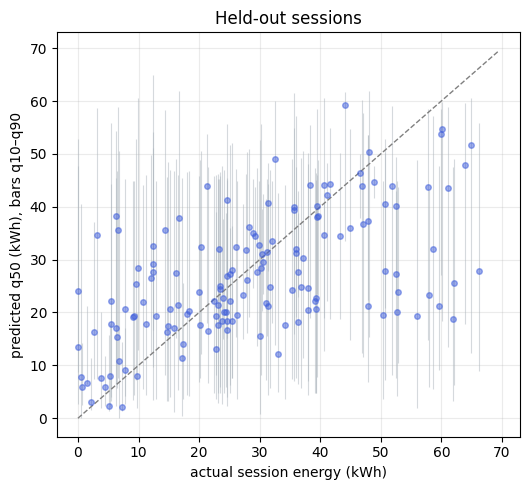

In [6]:
final = fitted_42[SELECTED]
lo, mid, hi = predict_sorted(final, X_te)
final_scores = scores(y_te, lo, mid, hi)
display(pd.DataFrame({f"{LABELS[SELECTED]} (served)": final_scores, "baseline": baseline_scores}).rename(index={
    "mae_kwh": "MAE (kWh)", "rmse_kwh": "RMSE (kWh)", "bias_kwh": "bias (kWh)", "coverage_q10_q90_pct": "q10–q90 coverage (%)"}))
print(f"MAE {100 * (1 - final_scores['mae_kwh'] / baseline_scores['mae_kwh']):.0f} % lower than the baseline")

b_lo, b_mid, b_hi = baseline(test)
per_household = {}
for hid in HOUSEHOLDS:
    m = (test.household == hid).to_numpy()
    if m.any():
        per_household[hid] = {"sessions": int(m.sum()),
                              "model MAE (kWh)": round(float(np.mean(np.abs(mid[m] - y_te[m]))), 2),
                              "baseline MAE (kWh)": round(float(np.mean(np.abs(b_mid[m] - y_te[m]))), 2)}
per_household = pd.DataFrame(per_household).T
display(per_household)

fig, ax = plt.subplots(figsize=(5.4, 5.0))
ax.errorbar(y_te, mid, yerr=[mid - lo, hi - mid], fmt="o", ms=4, alpha=0.5, color="#3b5bdb", ecolor="#adb5bd", lw=0.8)
lim = max(y_te.max(), hi.max()) * 1.05
ax.plot([0, lim], [0, lim], ls="--", lw=1, color="grey")
ax.set_xlabel("actual session energy (kWh)")
ax.set_ylabel("predicted q50 (kWh), bars q10–q90")
ax.set_title("Held-out sessions")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 7 · Export — `Data/models/`

`Data/models/` is exactly the content of the Hugging Face repository
[`EnerTEF/Service4-SessionEnergy`](https://huggingface.co/EnerTEF/Service4-SessionEnergy):

| File | Content |
|---|---|
| `session_energy.joblib` | the fitted q10 / q50 / q90 estimators with the feature order |
| `metrics.json` | hold-out metrics vs the baseline, split, parameters, library versions |
| `benchmark.json` | the full bake-off: per-seed results, the rule and the verdicts |
| `README.md` | the Hugging Face model card |

In [7]:
trained_at = datetime.now(timezone.utc).isoformat(timespec="seconds")
_, _, selected_params = ESTIMATORS[SELECTED]
joblib.dump({"model": "session_energy", "version": MODEL_VERSION, "algorithm": SELECTED, "features": FEATURES,
             "tariff_ordinal": TARIFF_ORDINAL, "quantiles": final, "trained_at": trained_at},
            MODEL_DIR / "session_energy.joblib")
split_info = {"method": "chronological 80/20 over all households", "n_train": len(train), "n_test": len(test),
              "train_window": [train.start.min().isoformat(), train.start.max().isoformat()],
              "test_window": [test.start.min().isoformat(), test.start.max().isoformat()]}
metrics = {"model_version": MODEL_VERSION, "trained_at": trained_at, "algorithm": SELECTED,
           "params": {**selected_params, "random_state": 42}, "quantiles": QUANTILES, "features": FEATURES,
           "split": split_info, "holdout": final_scores, "baseline_holdout": baseline_scores,
           "holdout_by_household": per_household.to_dict(orient="index"),
           "environment": {"python": platform.python_version(), **LIBS}}
(MODEL_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, default=str), encoding="utf-8")
benchmark = {"created_at": trained_at, "seeds": list(SEEDS), "incumbent": INCUMBENT, "selected": SELECTED,
             "rule": {"min_gain_pct": MIN_GAIN_PCT, "max_coverage_drop_pts": MAX_COVERAGE_DROP_PTS,
                      "gain_must_exceed_seed_range": True},
             "params": {name: params for name, (_, _, params) in ESTIMATORS.items()},
             "results": results, "verdicts": verdicts, "split": split_info,
             "environment": {"python": platform.python_version(), **LIBS}}
(MODEL_DIR / "benchmark.json").write_text(json.dumps(benchmark, indent=2, default=str), encoding="utf-8")
print("wrote:", ", ".join(sorted(p.name for p in MODEL_DIR.iterdir() if p.is_file())))

wrote:

 benchmark.json, metrics.json, session_energy.joblib


In [8]:
LIBRARY_TAG = {"sklearn_gbr": "scikit-learn", "lightgbm": "lightgbm", "xgboost": "xgboost"}[SELECTED]
CITATION = ("Avgoloupis, D. et al. Residential Energy Dataset with Electric Vehicles, Photovoltaic Generation and "
            "Tariff Variability in Ireland. Scientific Data 13:834 (2026). https://doi.org/10.1038/s41597-026-07186-3")
FEATURE_ROWS = "\n".join(f"| `{f}` | {d} |" for f, d in [
    ("recent_trip_km", "Distance driven since the previous session ended (km)."),
    ("trips_today", "Journeys started earlier on the session day."),
    ("hours_since_last_charge", "Hours since the previous session ended."),
    ("tariff_ordinal", "Tariff band at the session start: off-peak 0, shoulder 1, standard 2 (unknown), peak 3."),
    ("pv_today_kwh", "PV generated since midnight (kWh)."),
    ("hour_of_day", "Fractional hour of the session start (UTC)."),
    ("is_weekend", "1 on Saturday / Sunday, else 0."),
])

card = f'''---
library_name: {LIBRARY_TAG}
license: mit
pipeline_tag: tabular-regression
tags:
- energy
- ev-charging
- smart-charging
- quantile-regression
- gradient-boosting
- enertef
---

# Service 4 — residential EV session energy (quantile gradient boosting)

Predicts the **energy a home charging session will deliver** (kWh) at the q10 / q50 / q90 quantiles,
from context available just before the session: recent driving, time since the last charge, the tariff
band and the PV generated that day. Built for the EnerTEF TEF-EV EV-user charging and usage profiles
prediction service (D2.2 §2.5.4); downstream smart charging gets a point estimate and an uncertainty band.

Code and the full experiment: [{GITHUB_REPO.split("/")[-1]}]({GITHUB_REPO}) (notebook `EV_Session_Energy_Model.ipynb`).

## Model

| Field | Value |
|---|---|
| Algorithm | {LABELS[SELECTED]} — 3 quantile regressors (q10 / q50 / q90), chosen by the bake-off below |
| Parameters | `{json.dumps({**selected_params, "random_state": 42})}` |
| Training sessions | {len(train)} (chronologically earliest 80 %, four households) |
| Held-out sessions | {len(test)} (most recent 20 %) |
| Version | {MODEL_VERSION} ({trained_at[:10]}) |

### Features (order matters)

| Feature | Meaning |
|---|---|
{FEATURE_ROWS}

## Hold-out accuracy

| Metric | {LABELS[SELECTED]} | Baseline (distance × 0.18 kWh/km) |
|---|---|---|
| MAE (kWh) | {final_scores["mae_kwh"]:.2f} | {baseline_scores["mae_kwh"]:.2f} |
| RMSE (kWh) | {final_scores["rmse_kwh"]:.2f} | {baseline_scores["rmse_kwh"]:.2f} |
| q10–q90 coverage | {final_scores["coverage_q10_q90_pct"]:.1f} % | {baseline_scores["coverage_q10_q90_pct"]:.1f} % |

Four Irish households only — no generalisation beyond them is claimed.

## Model selection — why {LABELS[SELECTED]}

scikit-learn GBR (the incumbent), LightGBM and XGBoost were trained on the same sessions and split, with
the same capacity translated to each library and no per-library tuning, over three seeds. The rule was
fixed before the run: a challenger replaces GBR only if its q50 MAE is at least {MIN_GAIN_PCT:g} % lower,
the gap exceeds the seed-to-seed range, and its q10–q90 coverage drops by at most {MAX_COVERAGE_DROP_PTS:g} points.

{selection_markdown()}

Per-seed results: `benchmark.json`.

## Files

| File | Content |
|---|---|
| `session_energy.joblib` | dict with `features` (order), `tariff_ordinal`, `quantiles` (`q10`/`q50`/`q90` estimators) and metadata |
| `metrics.json` | hold-out metrics vs the baseline, split, parameters, library versions |
| `benchmark.json` | algorithm bake-off: per-seed results, rule, verdicts |

## Usage

```python
import joblib
import numpy as np

bundle = joblib.load("session_energy.joblib")
# Feature order: recent_trip_km, trips_today, hours_since_last_charge, tariff_ordinal,
#                pv_today_kwh, hour_of_day, is_weekend
x = [[12.5, 2.0, 8.0, 0.0, 0.0, 18.5, 0.0]]
lo, mid, hi = np.sort([est.predict(x)[0] for est in bundle["quantiles"].values()])
```

## Data

**Residential energy dataset with electric vehicles, PV generation and tariff variability in Ireland** —
annotated EV home-charging sessions, journeys, household energy streams, PV generation and tariff data
for four "ambassador" households (`id01`–`id04`) of the ESB Networks Dingle Electrification Project.

{CITATION}

**The dataset is not redistributed here.** It describes four real households, so it stays with its owners;
household identifiers are pseudonymous — do not attempt re-identification. Obtain it via the data paper.

## Limitations

- Four households only: a demonstrator, not a general-purpose predictor.
- The q10–q90 band is empirical; its coverage is reported above against a nominal 80 %.
- Whether and when a session starts is a separate question, not answered by this model.

## Citation

{CITATION}
'''
(MODEL_DIR / "README.md").write_text(card, encoding="utf-8")
display(Markdown(card.split("## Model selection")[0].split("---", 2)[2]))



# Service 4 — residential EV session energy (quantile gradient boosting)

Predicts the **energy a home charging session will deliver** (kWh) at the q10 / q50 / q90 quantiles,
from context available just before the session: recent driving, time since the last charge, the tariff
band and the PV generated that day. Built for the EnerTEF TEF-EV EV-user charging and usage profiles
prediction service (D2.2 §2.5.4); downstream smart charging gets a point estimate and an uncertainty band.

Code and the full experiment: [TEF-EV-Service-4----EV-User-Charging-and-Usage-Profiles-Prediction-Service](https://github.com/ENERTEF/TEF-EV-Service-4----EV-User-Charging-and-Usage-Profiles-Prediction-Service) (notebook `EV_Session_Energy_Model.ipynb`).

## Model

| Field | Value |
|---|---|
| Algorithm | scikit-learn GBR — 3 quantile regressors (q10 / q50 / q90), chosen by the bake-off below |
| Parameters | `{"loss": "quantile", "init": "zero", "n_estimators": 200, "max_depth": 3, "learning_rate": 0.05, "min_samples_leaf": 25, "subsample": 0.85, "random_state": 42}` |
| Training sessions | 587 (chronologically earliest 80 %, four households) |
| Held-out sessions | 147 (most recent 20 %) |
| Version | 1.0.0 (2026-09-30) |

### Features (order matters)

| Feature | Meaning |
|---|---|
| `recent_trip_km` | Distance driven since the previous session ended (km). |
| `trips_today` | Journeys started earlier on the session day. |
| `hours_since_last_charge` | Hours since the previous session ended. |
| `tariff_ordinal` | Tariff band at the session start: off-peak 0, shoulder 1, standard 2 (unknown), peak 3. |
| `pv_today_kwh` | PV generated since midnight (kWh). |
| `hour_of_day` | Fractional hour of the session start (UTC). |
| `is_weekend` | 1 on Saturday / Sunday, else 0. |

## Hold-out accuracy

| Metric | scikit-learn GBR | Baseline (distance × 0.18 kWh/km) |
|---|---|---|
| MAE (kWh) | 10.46 | 18.72 |
| RMSE (kWh) | 14.20 | 25.88 |
| q10–q90 coverage | 79.6 % | 36.1 % |

Four Irish households only — no generalisation beyond them is claimed.



## 8 · Publish to Hugging Face (opt-in)

Uploads `Data/models/` to `EnerTEF/Service4-SessionEnergy`. Remote `.json` / `.joblib` files that are
not in the folder are removed. Requires a write-scoped token: run `hf auth login` once (or set
`HF_TOKEN`), then set `UPLOAD_TO_HF = True`. The dataset is never uploaded.

In [9]:
UPLOAD_TO_HF = False

if UPLOAD_TO_HF:
    from huggingface_hub import HfApi

    api = HfApi()
    api.create_repo(repo_id=HF_REPO, repo_type="model", exist_ok=True)
    api.upload_folder(repo_id=HF_REPO, repo_type="model", folder_path=str(MODEL_DIR),
                      commit_message=f"Service 4 session-energy model v{MODEL_VERSION}", delete_patterns=["*.json", "*.joblib"])
    print(f"published: https://huggingface.co/{HF_REPO}")
else:
    print(f"not uploaded — review Data/models/README.md, then set UPLOAD_TO_HF = True to publish to {HF_REPO}")

not uploaded — review Data/models/README.md, then set UPLOAD_TO_HF = True to publish to EnerTEF/Service4-SessionEnergy
